# Restaurant Exploratory Data Analysis

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

os.makedirs('../output', exist_ok=True)

## Data Cleaning (SQL Server)

The raw CSV was imported into a local SQL Server Express instance as `dbo.restaurant_sales` in the database, and all cleaning was done in SQL Server Management Studio (SSMS). The queries below were run in SSMS rather than in this notebook, so they are shown here for reference. The cleaned table is then loaded into pandas for the analysis.

### Creating a Working Copy

To avoid modifying the raw data, the cleaning is done on a copy of the table:

```sql
SELECT *
INTO dbo.cleaned_sales
FROM dbo.restaurant_sales;
```

Comparing row counts confirms the copy is complete. Both queries return 38,293 rows.

```sql
SELECT COUNT(*)
FROM dbo.cleaned_sales;

SELECT COUNT(*)
FROM dbo.restaurant_sales;
```

### Removing Irrelevant Columns

The raw dataset contains several columns that are redundant, unused, or unnecessary for this analysis. The following columns are dropped, with justification:

- **Item_Code**: Redundant; the `Item` column already provides a complete, readable identifier.
- **Qty**: Constant across every record (always 1); carries no analytical value.
- **Day_Of_Week, Date, Hour, Time**: Will be reconstructed from a single `Order_Date` timestamp so that all time-based fields remain consistent with one another.
- **Order_Tips, Order_Total, Item_Tax**: Not required; this analysis is scoped to item-level sales values.
- **Order_Subtotal, Order_Tax**: These are order-level totals repeated across every line item of an order; retaining them would double-count tax and revenue if aggregated at the line-item grain.
- **Order_Employee, Payment_Employee**: The restaurant does not track employee-level data, so these fields carry no signal.
- **Discount**: Constant at 0 across all records; unused.
- **Order**: `Invoice` already groups every order's line items reliably, making `Order` redundant.

The constant values of `Qty` and `Discount` can be confirmed first. Each query returns a single value (1 and 0):

```sql
SELECT DISTINCT Qty
FROM dbo.restaurant_sales;

SELECT DISTINCT Discount
FROM dbo.restaurant_sales;
```

```sql
ALTER TABLE dbo.cleaned_sales
DROP COLUMN
    Item_Code,
    Qty,
    Day_Of_Week,
    Date,
    Hour,
    Time,
    Order_Tips,
    Order_Total,
    Item_Tax,
    Order_Subtotal,
    Order_Tax,
    Order_Employee,
    Payment_Employee,
    Discount,
    [Order];
```

`ORDER` is a reserved keyword in SQL, so the column name has to be wrapped in brackets.

### Renaming Columns

`Table` and `Invoice` are renamed to `Table_Number` and `Invoice_Number` to make their meaning clearer. Most SQL databases support `ALTER TABLE ... RENAME COLUMN`, but SQL Server does not, so the `sp_rename` stored procedure is used instead:

```sql
EXEC sp_rename 'dbo.cleaned_sales.[Table]', 'Table_Number', 'COLUMN';
EXEC sp_rename 'dbo.cleaned_sales.Invoice', 'Invoice_Number', 'COLUMN';
```

`TABLE` is also a reserved keyword, so it is bracketed as well.

### Correcting Data Types

The current column types can be checked through `INFORMATION_SCHEMA.COLUMNS`:

```sql
SELECT COLUMN_NAME, DATA_TYPE, CHARACTER_MAXIMUM_LENGTH, IS_NULLABLE
FROM INFORMATION_SCHEMA.COLUMNS
WHERE TABLE_SCHEMA = 'dbo'
  AND TABLE_NAME = 'cleaned_sales';
```

| COLUMN_NAME | DATA_TYPE | CHARACTER_MAXIMUM_LENGTH |
|---|---|---|
| Line_ID | nvarchar | 50 |
| Item | nvarchar | 50 |
| Size | nvarchar | 50 |
| Category | nvarchar | 50 |
| Order_Date | datetime2 | NULL |
| Item_Price | float | NULL |
| Invoice_Number | int | NULL |
| Order_Type | nvarchar | 50 |
| Table_Number | nvarchar | 50 |
| Payment_Type | nvarchar | 50 |

SSMS already imported `Order_Date` as a `datetime2`, so it needs no conversion. `Invoice_Number` was imported as an `int`, but it is an identifier rather than a numeric quantity and should not support arithmetic, so it is converted to text. This also means it loads into pandas as a string:

```sql
ALTER TABLE dbo.cleaned_sales
ALTER COLUMN Invoice_Number NVARCHAR(50);
```

### Additional Data Quality Checks

Checking that `Item_Price` and `Invoice_Number` contain no negative or zero values. Since `Invoice_Number` is now text, it is cast back to a number for the comparison with `TRY_CAST`:

```sql
SELECT COUNT(*) AS negative_item_price_count
FROM dbo.cleaned_sales
WHERE Item_Price <= 0;

SELECT COUNT(*) AS negative_invoice_number_count
FROM dbo.cleaned_sales
WHERE TRY_CAST(Invoice_Number AS FLOAT) <= 0;
```

Both queries return 0, so there are no negative or zero values.

Text columns are also checked for leading or trailing whitespace. `DATALENGTH` is used instead of `LEN` because `LEN` ignores trailing spaces:

```sql
SELECT COUNT(*) AS whitespace_count
FROM dbo.cleaned_sales
WHERE DATALENGTH(Item) <> DATALENGTH(TRIM(Item))
   OR DATALENGTH(Size) <> DATALENGTH(TRIM(Size))
   OR DATALENGTH(Category) <> DATALENGTH(TRIM(Category))
   OR DATALENGTH(Order_Type) <> DATALENGTH(TRIM(Order_Type))
   OR DATALENGTH(Table_Number) <> DATALENGTH(TRIM(Table_Number))
   OR DATALENGTH(Payment_Type) <> DATALENGTH(TRIM(Payment_Type));
```

This returns 0. The raw CSV has trailing whitespace on `Thang Noodles`, but the SSMS import trims it, so no fix is needed.

### Standardizing Category Names

Listing every distinct `Category` value shows two inconsistencies that would otherwise appear as-is in chart labels:

```sql
SELECT DISTINCT Category
FROM dbo.cleaned_sales
ORDER BY Category;
```

- `pho`: lowercase, while every other category is Title Case.
- `Noodle Salad|Bowl`: contains a literal `|`, an export artifact that could also cause problems in later SQL statements.

```sql
UPDATE dbo.cleaned_sales
SET Category = 'Pho'
WHERE Category = 'pho';

UPDATE dbo.cleaned_sales
SET Category = 'Noodle Salad Bowl'
WHERE Category = 'Noodle Salad|Bowl';
```

### Rebuilding Day_Of_Week and Order_Hour

The day of week and hour dropped earlier are rebuilt from `Order_Date` as **computed columns**, which SQL Server calculates from `Order_Date` whenever they are read, so they can never drift out of sync with the timestamp:

```sql
ALTER TABLE dbo.cleaned_sales
ADD [Day_Of_Week] AS DATENAME(weekday, Order_Date);

ALTER TABLE dbo.cleaned_sales
ADD [Order_Hour] AS DATEPART(HOUR, Order_Date);
```

### Consolidating Order Types

`Order_Type` contains three distinct values: `TABLE`, `QUICK ORDER`, and `TO GO`. Operationally, a `QUICK ORDER` is a `TO GO` order, so the two are consolidated to avoid an artificial three-way split:

```sql
UPDATE dbo.cleaned_sales
SET Order_Type = 'TO GO'
WHERE Order_Type = 'QUICK ORDER';
```

## Loading the Cleaned Data

The cleaned table was exported from SSMS as a CSV and is loaded into pandas here. The export has no header row, so the column names are supplied directly, in the same order as the table. SSMS writes empty values as `NULL`, which pandas reads as missing by default. The file also starts with a UTF-8 byte order mark, so it is read as `utf-8-sig` to keep it out of the first column name.

In [2]:
columns = [
  'Line_ID',
  'Item',
  'Size',
  'Category',
  'Order_Date',
  'Item_Price',
  'Invoice_Number',
  'Order_Type',
  'Table_Number',
  'Payment_Type',
  'Order_Hour',
  'Day_Of_Week',
]

df = pd.read_csv(
  '../data/cleaned_sales.csv',
  header=None,
  names=columns,
  encoding='utf-8-sig',
  index_col='Line_ID',
  parse_dates=['Order_Date'],
  dtype={'Invoice_Number': 'str'},
)

In [3]:
df.head()

,Item,Size,Category,Order_Date,Item_Price,Invoice_Number,Order_Type,Table_Number,Payment_Type,Order_Hour,Day_Of_Week
Line_ID,,,,,,,,,,,
18278,Dr Pepper,NaN,Coffee & Drinks,2026-07-17 15:54:00,3.29,191617,TO GO,NaN,Cash,15,Friday
18279,Vege & Tofu,Large,Pho,2026-07-17 15:54:00,15.99,191617,TO GO,NaN,Cash,15,Friday
1828,BBQ Pork Spring Roll,NaN,Appetizer,2026-06-06 21:59:00,4.99,185877,TO GO,NaN,Credit Card,21,Saturday
18280,TOGO,NaN,TOGO,2026-07-17 15:54:00,0.50,191617,TO GO,NaN,Cash,15,Friday
18281,EXtra Mushroom,NaN,Side Orders,2026-07-17 15:55:00,2.49,191618,TABLE,A4,Credit Card,15,Friday


In [4]:
print(df.dtypes)

Item                         str
Size                         str
Category                     str
Order_Date        datetime64[ns]
Item_Price               float64
Invoice_Number               str
Order_Type                   str
Table_Number                 str
Payment_Type                 str
Order_Hour                 int64
Day_Of_Week                  str
dtype: object


## Analysis Plan

With the data cleaned, the analysis proceeds in four stages:

1. **Sales Heatmap**: Aggregate sales by day of week and hour to visualize when the restaurant is busiest, using a red (low) to green (high) color scale. Item category is not a factor at this stage; only day, hour, and the aggregated sales figure matter.
2. **Heatmap by Order Type**: Split the same view into dine-in and to-go to identify *what kind* of demand drives each peak, since the two imply different staffing responses.
3. **Item Rankings**: Rank menu items both by **units sold** and by **revenue**, with the best and worst performers shown for each. These two measures answer different questions: units sold reflects popularity, while revenue reflects contribution to the business's income. Because some item names are shared across categories (e.g. `Brisket` appears under both `Pho` and `Side Orders`), items are grouped by both `Item` and `Category` to keep them distinct.
4. **Weekly Revenue Trend**: Track total revenue week over week to determine whether the business is growing, declining, or holding steady across the quarter.

Findings from all four stages are then synthesized into recommendations in the conclusion.

### Sales Heatmap: Average Sales by Day and Hour

Each cell shows the **average sales for that day-and-hour slot**, calculated as total sales in the slot divided by the number of times that weekday occurred in the quarter (13 for most days, 14 for Wednesday). Averaging per weekday occurrence, rather than summing, prevents days that happened one extra time from appearing busier than they actually were.

I first tried this with `pivot_table(..., aggfunc='mean')` directly, but that came out almost flat. Every cell landed around \$9. The problem: `aggfunc='mean'` divides by the number of *line items sold* in that slot, which gives the average price of an item, not how busy the restaurant was. Since the mix of cheap and expensive items ordered doesn't change much by hour, that number barely moves. What I actually wanted was total sales divided by the number of *Mondays/Tuesdays/etc.*, so I went back to `aggfunc='sum'` and divided manually below.

Blank grey cells indicate hours when the restaurant was closed and no orders exist, which is distinct from an hour that was open but slow.

**Caveat:** each cell only averages 13–14 data points (one per matching weekday in the quarter). That's a small enough sample that a single unusual day (a large party, a slow holiday) could shift a cell's average more than a real pattern would. I'm treating this as a first-pass view rather than a fully confirmed pattern.

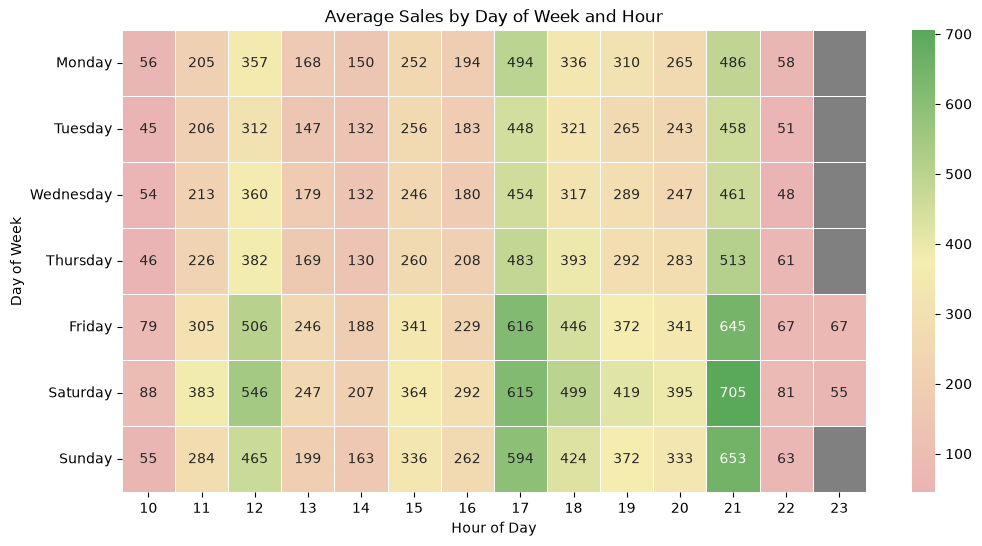

In [5]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
# Ordered categorical so the heatmap rows read Mon->Sun instead of pandas' default alphabetical sort
df['Day_Of_Week'] = pd.Categorical(df['Day_Of_Week'], categories=day_order, ordered=True)

sales_sum = df.pivot_table(
  index='Day_Of_Week',
  columns='Order_Hour',
  values='Item_Price',
  aggfunc='sum'
)

# Number of times each weekday actually occurred, used as the averaging denominator
day_counts = (
  df['Order_Date']
  .dt.normalize()
  .drop_duplicates()
  .dt.day_name()
  .value_counts()
  .reindex(day_order)
)

avg_sales = sales_sum.div(day_counts, axis=0)

soft_cmap = LinearSegmentedColormap.from_list(
  'soft_rdylgn', ['#eab4b4', '#f5edb0', '#5aa85a']
)

plt.figure(figsize=(12, 6))
ax = plt.gca()
ax.set_facecolor('grey')
sns.heatmap(avg_sales, cmap=soft_cmap, annot=True, fmt='.0f', linewidths=0.5, linecolor='white')
plt.title('Average Sales by Day of Week and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.savefig('../output/sales_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Sales Heatmap by Order Type

The heatmap above shows overall busyness by day and hour, but not *why* those hours are busy. Splitting the same heatmap into dine-in (`TABLE`) and to-go (`TO GO`) versions shows whether a busy slot is driven by tables filling up or by pickup/delivery volume, which points to different staffing responses (e.g. an extra server vs. a to-go-only staffer). Both heatmaps share the same color scale so they can be compared directly against each other.

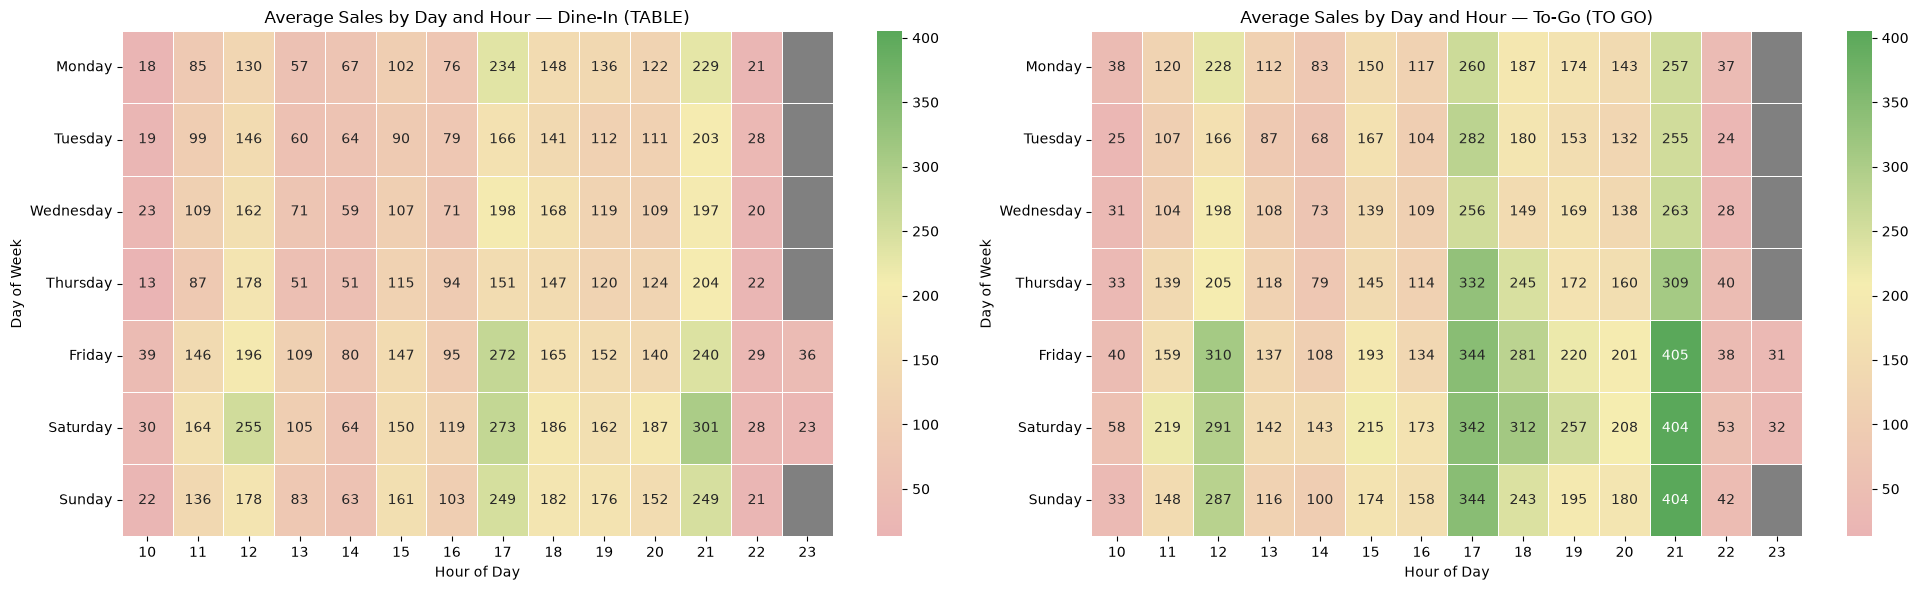

In [6]:
def avg_sales_by_hour_day(order_type, day_counts):
  '''Average sales per day-and-hour slot for a single order type.'''
  subset = df[df['Order_Type'] == order_type]

  sales_sum = subset.pivot_table(
    index='Day_Of_Week',
    columns='Order_Hour',
    values='Item_Price',
    aggfunc='sum'
  )

  return sales_sum.div(day_counts, axis=0)

avg_sales_table = avg_sales_by_hour_day('TABLE', day_counts)
avg_sales_togo = avg_sales_by_hour_day('TO GO', day_counts)

# Use the same color scale on both heatmaps so they're directly comparable
vmin = min(avg_sales_table.min().min(), avg_sales_togo.min().min())
vmax = max(avg_sales_table.max().max(), avg_sales_togo.max().max())

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, data, title in zip(
  axes,
  [avg_sales_table, avg_sales_togo],
  ['Dine-In (TABLE)', 'To-Go (TO GO)']
):
  ax.set_facecolor('grey')
  sns.heatmap(
    data, cmap=soft_cmap, annot=True, fmt='.0f',
    linewidths=0.5, linecolor='white',
    vmin=vmin, vmax=vmax, ax=ax
  )
  ax.set_title(f'Average Sales by Day and Hour — {title}')
  ax.set_xlabel('Hour of Day')
  ax.set_ylabel('Day of Week')

plt.tight_layout()
plt.savefig('../output/sales_heatmap_by_order_type.png', dpi=150, bbox_inches='tight')
plt.show()

### Top 15 Items by Units Sold

`TOGO` is excluded from this ranking. It's the \$0.50 to-go bag fee that Washington state mandates restaurants charge, not a food item, so it doesn't belong in a menu popularity ranking. `Side Orders` are also excluded. They're low-priced, high-frequency add-ons (rice, extra soup, etc.) that would dominate a ranking by count without reflecting what's actually driving customers to order.

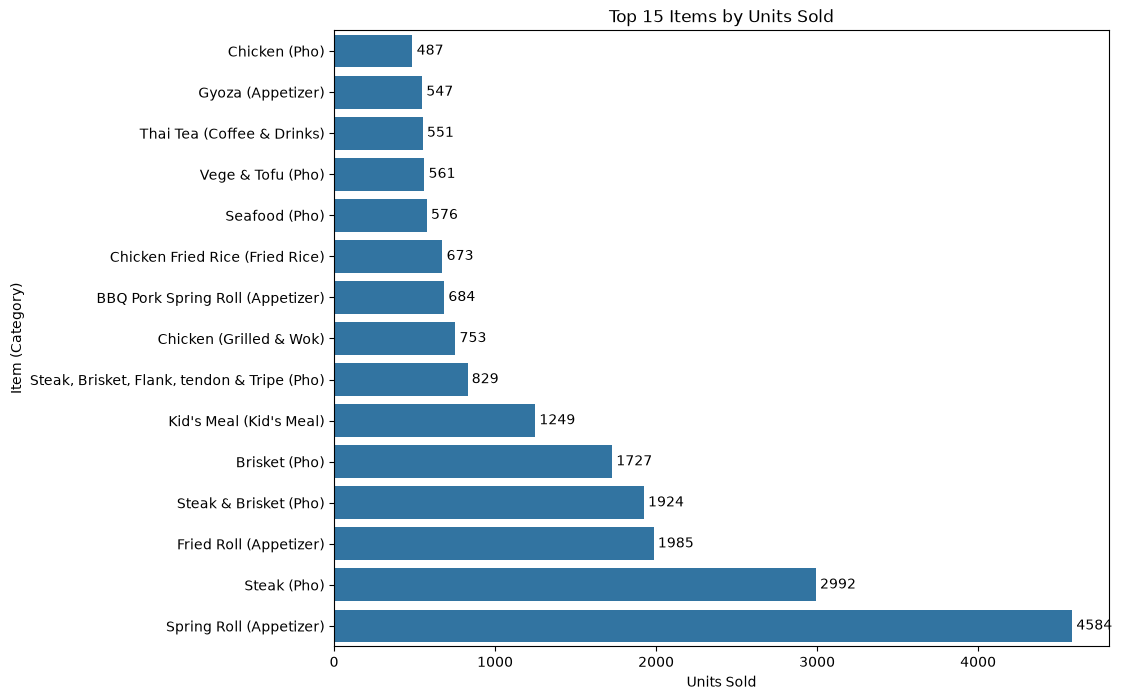

In [7]:
item_counts = (
  df[~df['Category'].isin(['TOGO', 'Side Orders'])]
  .groupby(['Item', 'Category'])
  .size()
  .sort_values(ascending=False)
)

top_items = item_counts.head(15)

labels = [f'{item} ({category})' for item, category in top_items.index]

plt.figure(figsize=(10, 8))
ax = sns.barplot(x=top_items.values, y=labels, orient='h')
ax.bar_label(ax.containers[0], padding=3)
ax.invert_yaxis()
plt.title('Top 15 Items by Units Sold')
plt.xlabel('Units Sold')
plt.ylabel('Item (Category)')
plt.savefig('../output/top15_items_units_sold.png', dpi=150, bbox_inches='tight')
plt.show()

### 15 Lowest Selling Items

Same filtering and grouping as above, sorted in the opposite direction to surface the weakest-performing items on the menu.

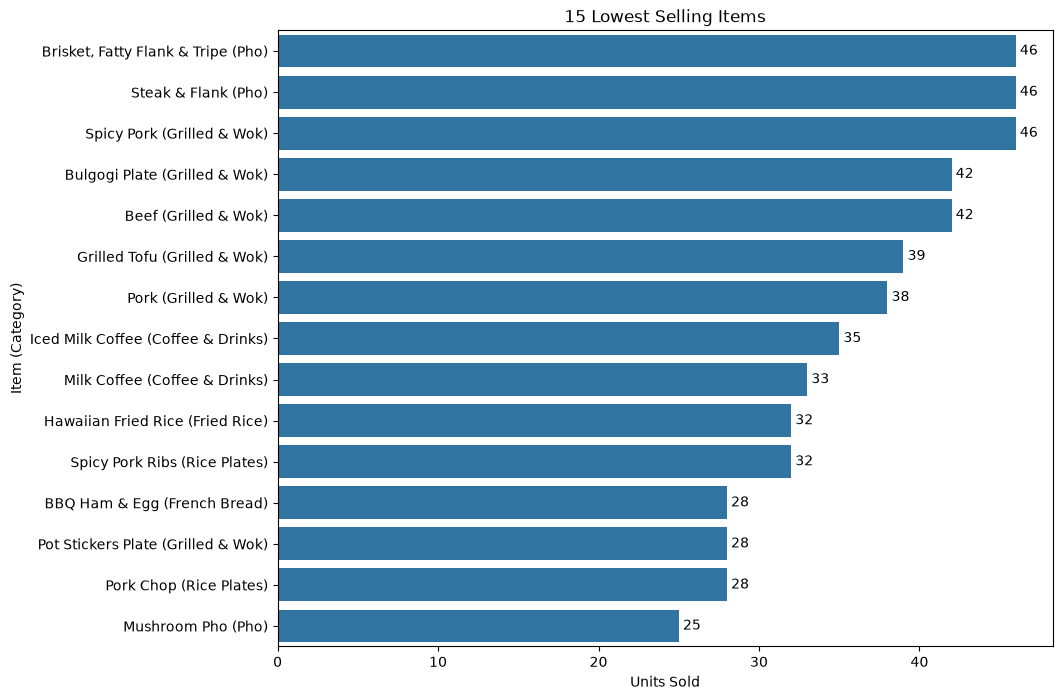

In [8]:
bottom_items = item_counts.sort_values(ascending=True).head(15)

labels = [f'{item} ({category})' for item, category in bottom_items.index]

plt.figure(figsize=(10, 8))
ax = sns.barplot(x=bottom_items.values, y=labels, orient='h')
ax.bar_label(ax.containers[0], padding=3)
ax.invert_yaxis()
plt.title('15 Lowest Selling Items')
plt.xlabel('Units Sold')
plt.ylabel('Item (Category)')
plt.savefig('../output/bottom15_items_units_sold.png', dpi=150, bbox_inches='tight')
plt.show()

### Top 15 Items by Revenue

Ranking by units sold treats a \$0.50 item and an \$18 item as equally important if they sell the same number of times. Ranking by revenue instead shows which items actually drive the business's income. This can (and does) produce a different list than the units-sold ranking above. Same filtering as before: `TOGO` and `Side Orders` excluded, grouped by `Item` and `Category`.

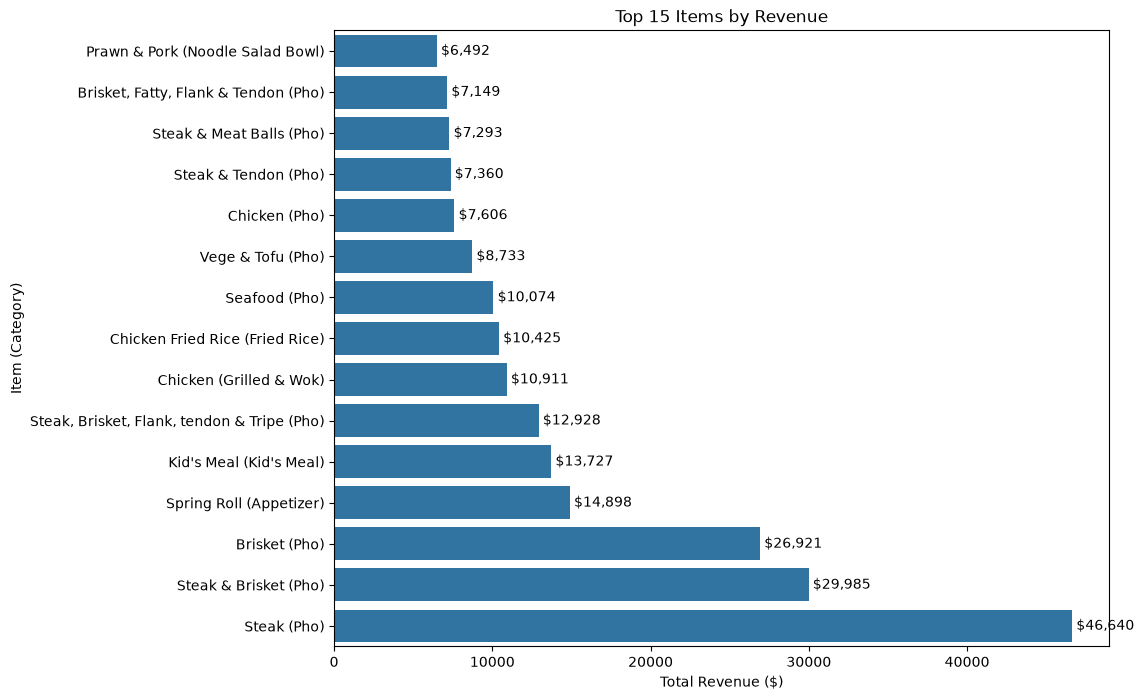

In [9]:
item_revenue = (
  df[~df['Category'].isin(['TOGO', 'Side Orders'])]
  .groupby(['Item', 'Category'])['Item_Price']
  .sum()
  .sort_values(ascending=False)
)

top_revenue = item_revenue.head(15)

labels = [f'{item} ({category})' for item, category in top_revenue.index]

plt.figure(figsize=(10, 8))
ax = sns.barplot(x=top_revenue.values, y=labels, orient='h')
ax.bar_label(ax.containers[0], fmt='${:,.0f}', padding=3)
ax.invert_yaxis()
plt.title('Top 15 Items by Revenue')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Item (Category)')
plt.savefig('../output/top15_items_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

### 15 Lowest Revenue Items

Same filtering and grouping as above, sorted ascending to surface the weakest revenue-generating items on the menu.

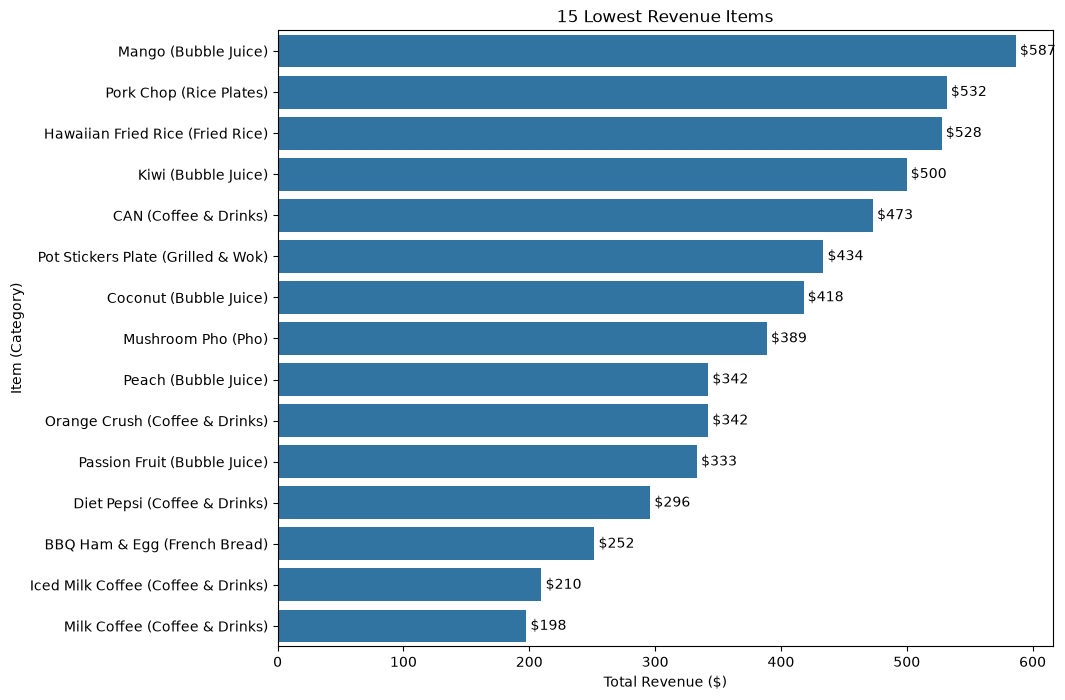

In [10]:
bottom_revenue = item_revenue.sort_values(ascending=True).head(15)

labels = [f'{item} ({category})' for item, category in bottom_revenue.index]

plt.figure(figsize=(10, 8))
ax = sns.barplot(x=bottom_revenue.values, y=labels, orient='h')
ax.bar_label(ax.containers[0], fmt='${:,.0f}', padding=3)
ax.invert_yaxis()
plt.title('15 Lowest Revenue Items')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Item (Category)')
plt.savefig('../output/bottom15_items_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

### Weekly Revenue Trend

This chart checks whether revenue shows any upward or downward trend across the quarter. It's worth noting this is an internal comparison only. There is no prior period (a previous quarter, or the same months last year) to benchmark against, so any pattern found here describes movement within this 13-week window, not growth or decline relative to a baseline.

This is also why dropping `Order_Subtotal` back in Data Cleaning didn't cost anything: it was an order-level total repeated on every line, and summing `Item_Price` (the line-level value) across a week reconstructs the same total without any double counting.

**On the `.iloc[1:-1]` below:** the data runs Jun 3 (a Wednesday) through Sep 2 (also a Wednesday), which doesn't align to calendar week boundaries. The first bucket therefore covers only Wed–Sun (5 days) and the last covers only Mon–Wed (3 days). Both are printed below for transparency, then trimmed. Left in, they would produce a steep drop at each end of the line that reflects missing days rather than any real change in business.

Order_Date
2026-06-07    20861.54
2026-06-14    26619.85
2026-06-21    26062.80
2026-06-28    25840.10
2026-07-05    26197.27
2026-07-12    25705.51
2026-07-19    26080.72
2026-07-26    27256.70
2026-08-02    26250.25
2026-08-09    26911.69
2026-08-16    27692.99
2026-08-23    26935.34
2026-08-30    26792.13
2026-09-06     9364.34
Freq: W-SUN, Name: Item_Price, dtype: float64


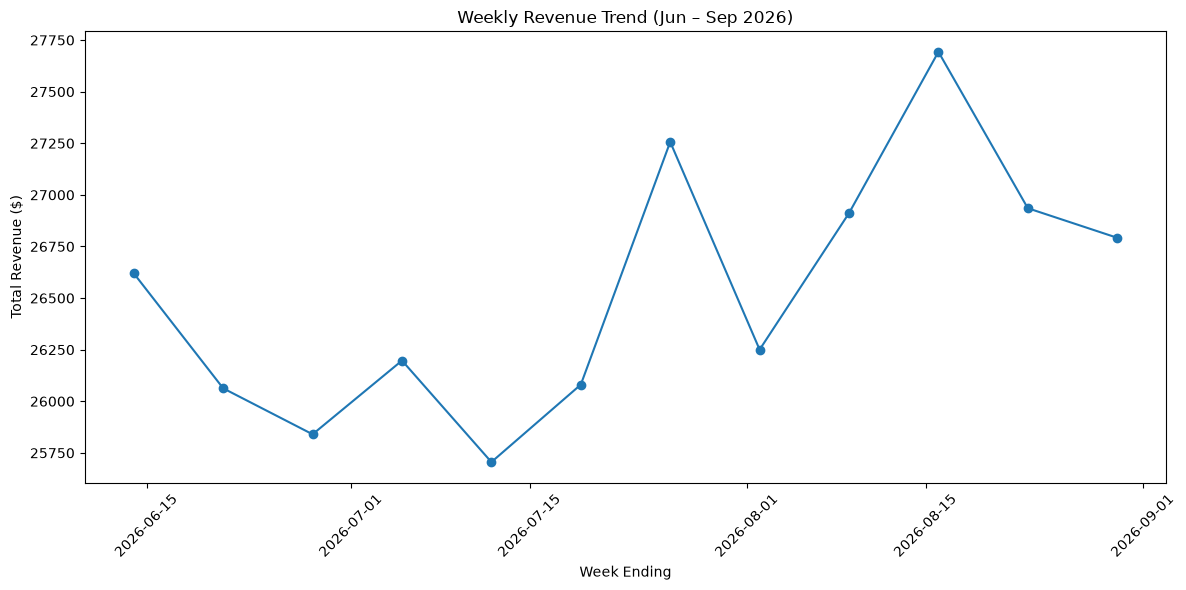

In [11]:
weekly_revenue = df.resample('W', on='Order_Date')['Item_Price'].sum()
print(weekly_revenue)
weekly_revenue = weekly_revenue.iloc[1:-1]

plt.figure(figsize=(12, 6))
plt.plot(weekly_revenue.index, weekly_revenue.values, marker='o')
plt.title('Weekly Revenue Trend (Jun – Sep 2026)')
plt.xlabel('Week Ending')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../output/weekly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

### Sales Dashboard

The key views are combined into a single image: when the restaurant is busiest, and which menu items sell the most and the least by units sold. Same filtering as the item rankings above: `TOGO` and `Side Orders` are excluded.

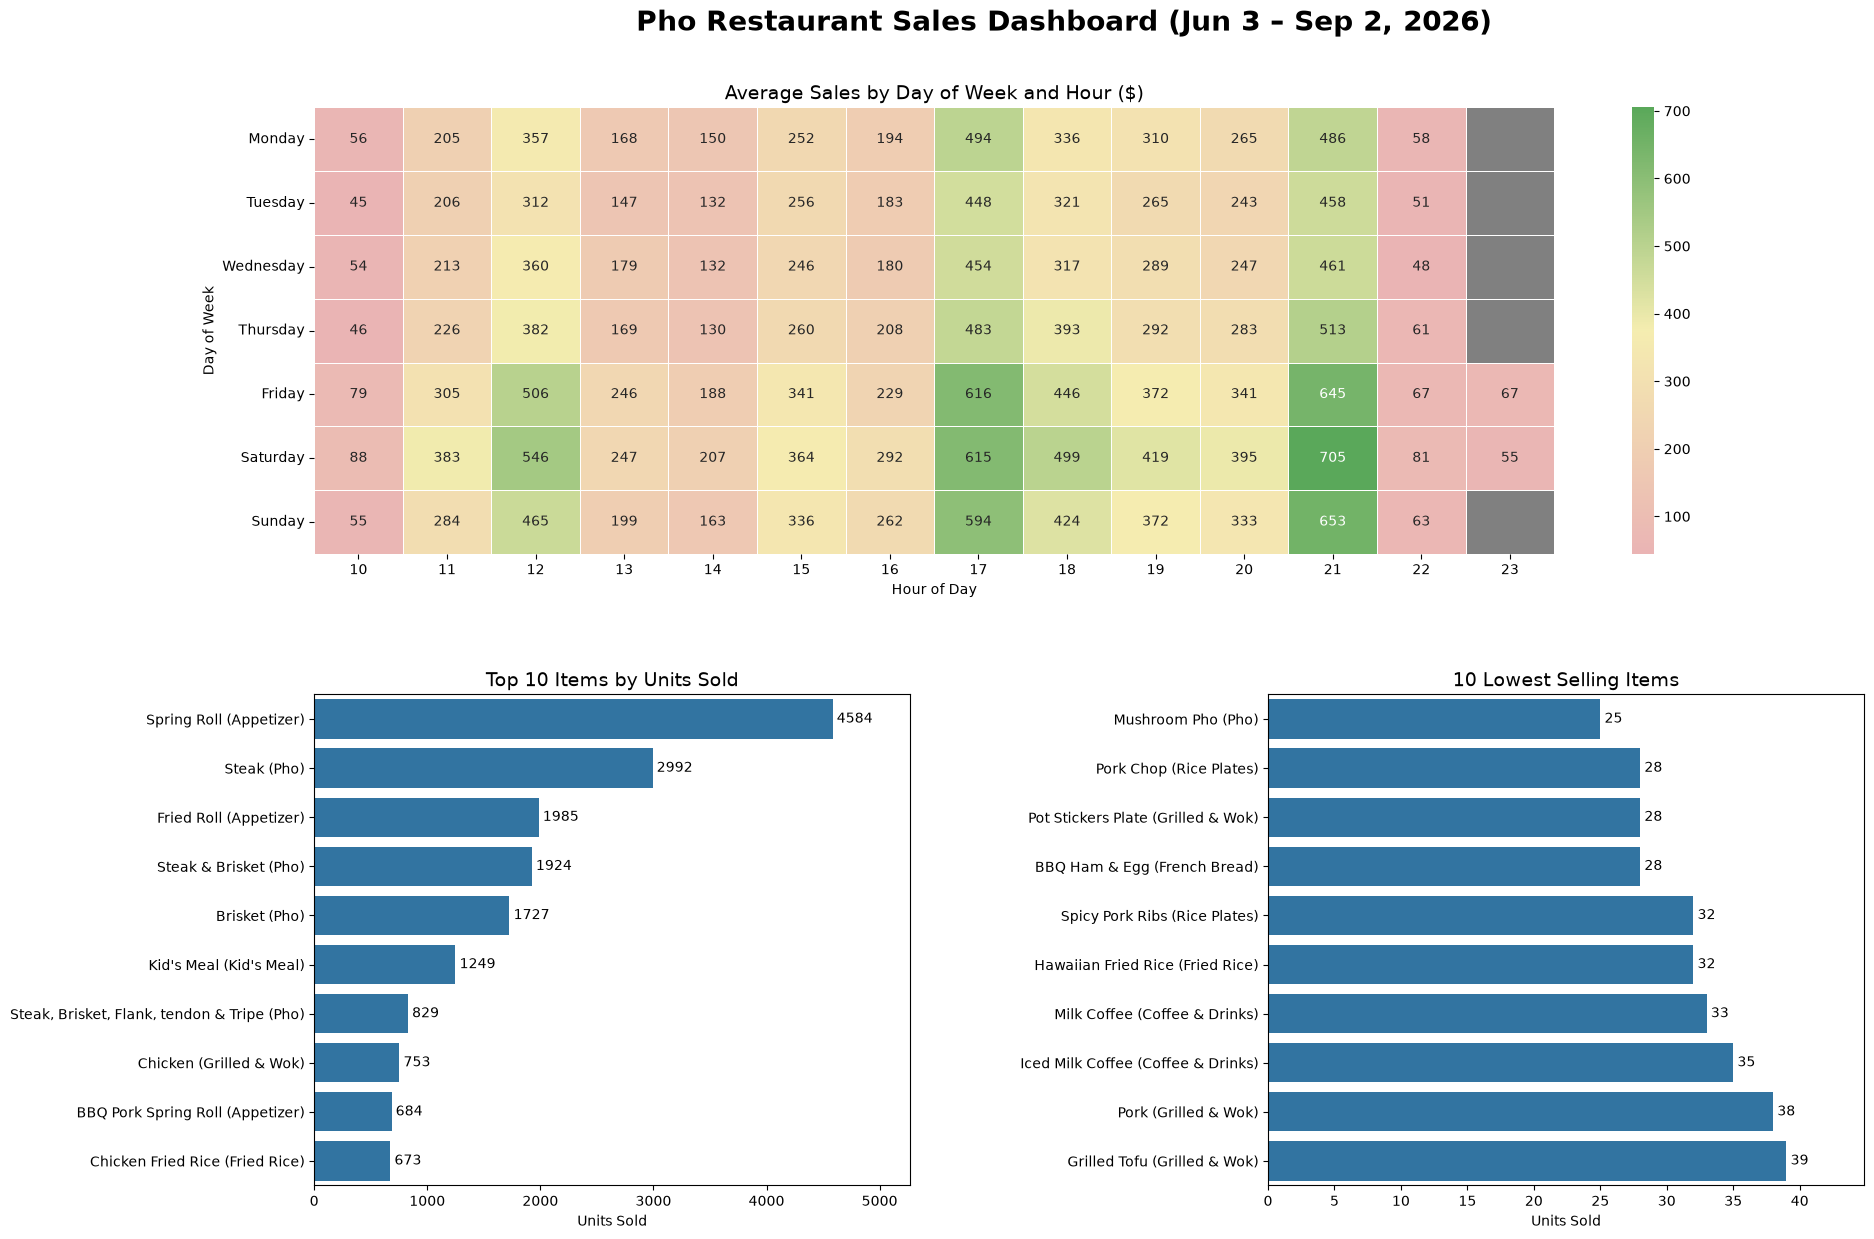

In [12]:
start, end = df['Order_Date'].min(), df['Order_Date'].max()
period = f'{start:%b} {start.day} – {end:%b} {end.day}, {end.year}'

fig = plt.figure(figsize=(20, 14))
grid = fig.add_gridspec(2, 2, height_ratios=[1, 1.1], hspace=0.3, wspace=0.6)
fig.suptitle(f'Pho Restaurant Sales Dashboard ({period})', fontsize=20, fontweight='bold', y=0.95)

# 1. Heatmap: average sales by day and hour
ax_heat = fig.add_subplot(grid[0, :])
ax_heat.set_facecolor('grey')
sns.heatmap(avg_sales, cmap=soft_cmap, annot=True, fmt='.0f', linewidths=0.5, linecolor='white', ax=ax_heat)
ax_heat.set_title('Average Sales by Day of Week and Hour ($)', fontsize=14)
ax_heat.set_xlabel('Hour of Day')
ax_heat.set_ylabel('Day of Week')

# 2 & 3. Top and bottom 10 items by units sold
ranked = [
  (grid[1, 0], item_counts.head(10), 'Top 10 Items by Units Sold'),
  (grid[1, 1], item_counts.sort_values(ascending=True).head(10), '10 Lowest Selling Items'),
]
for position, items, title in ranked:
  ax = fig.add_subplot(position)
  labels = [f'{item} ({category})' for item, category in items.index]
  sns.barplot(x=items.values, y=labels, orient='h', ax=ax)
  ax.bar_label(ax.containers[0], padding=3)
  ax.set_xlim(0, items.max() * 1.15)
  ax.set_title(title, fontsize=14)
  ax.set_xlabel('Units Sold')
  ax.set_ylabel('')

plt.savefig('../output/sales_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

# Conclusion

My parents felt like business had been slowing down and wanted a specific number they could see, rather than just a feeling from being there every day. This analysis was meant to check that feeling against the actual data.

### Questions this analysis set out to answer
- When is the restaurant busiest, by day and hour?
- Which menu items are the most popular and most profitable, and are they the same?
- Is revenue trending up, down, or holding steady?

### Key findings
- Demand peaks around 12PM, 5PM, and 9PM. This is expected, coming from the lunch and dinner rushes plus late night people looking for something to order.
- Those peaks are mostly driven by to-go orders rather than dine-in.
- Friday, Saturday, and Sunday are the busiest days. Tuesday is the slowest.
- Steak (Pho) was both a top seller and the top revenue item. Some items are popular but don't make much money. Appetizers like Spring Roll sell a lot but rank lower in revenue.
- Revenue stayed flat across the quarter at roughly \$26,000 per week, so the business is holding steady rather than growing or declining. **This contradicts what my parents assumed going in.** The data doesn't support "business is slowing down." That's worth telling them directly, since it changes the conversation from "how do we stop the decline" to "how do we grow from a stable baseline."

### Business recommendations
- 1PM-4PM is where a lot of the dead time occurs. We should run a targeted special sale/happy hour to drive more traffic to the store.
- Tuesday specifically is the slowest day. A special promotion to get customers in on Tuesdays should help.
- Since the peaks are mostly to-go orders, extra help at 5PM and 9PM should focus on packing to-go orders instead of table service.